# 02 — TSI Analysis & Fusion Experiments
## Sensibilidad Temporal de Descriptores de Audio Artesanales

Carga los features pre-extraídos (notebook `01_feature_extraction.ipynb`) y ejecuta el
**método rediseñado (payoff)**:

1. Ganancia de información `G(f,k)` con clasificadores **calibrados** + `L_chance` (base-rate).
2. **TSI por descriptor**: `k*` por **selección anidada**, payoff `G(f,k*) − G(f,k̄)`,
   compuerta `τ` (nula por permutación, re-selecciona argmax), IC bootstrap del payoff,
   `TSI_rel`, sesgo optimista residual.
3. **Matriz de ganancia 7×3** (`G ± σ`, anotada con `k*` y TSI).
4. **5 estrategias de fusión** + referencias (learned-LF sin prior, uniforme).
5. **Validación estadística**: Friedman/Nemenyi (Wilcoxon en IRMAS, K=2),
   Wilcoxon pareado + Bonferroni (C(5,2)=10) + Cliff's δ, Spearman entre rankings.
6. ECE / reliability + importancia PI/MDI (corroborativa).

Escribe `tsi_results.json` y `experiment_results.json` a `RESULTS_ROOT` y los copia a `results/`.

> **Costo:** el barrido anidado entrena muchos clasificadores. Ajusta `N_PERM`, `N_BOOT`,
> `CLASSIFIERS` y el submuestreo de MTAT según el tiempo disponible.

## 0. Setup & Load Cached Features

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install dependencies
!pip install -q librosa scikit-learn torch torchaudio tqdm seaborn xgboost scipy scikit-posthocs

# cuML: GPU-accelerated Random Forest (NVIDIA CUDA only). Falls back to sklearn RF.
!pip install -q cuml-cu12 --extra-index-url=https://pypi.nvidia.com 2>/dev/null || echo "cuML not available — sklearn RF will be used"

# Clone the repo to get the src/ modules
import os
REPO_URL = "https://github.com/Gabrieleeh32159/my_paper.git"
REPO_DIR = "/content/my_paper"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull

Cloning into '/content/my_paper'...
remote: Enumerating objects: 387, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (106/106), done.
remote: Total 387 (delta 72), reused 114 (delta 45), pack-reused 234 (from 1)
Receiving objects: 100% (387/387), 32.02 MiB | 18.51 MiB/s, done.
Resolving deltas: 100% (208/208), done.


In [3]:
import os
import sys
import numpy as np
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# === CONFIGURATION ===
REPO_DIR = Path('/content/my_paper')

DRIVE_ROOT = Path('/content/drive/MyDrive/tsi_experiments')
DATA_ROOT = DRIVE_ROOT / 'data'
FEATURES_ROOT = DRIVE_ROOT / 'features'
RESULTS_ROOT = DRIVE_ROOT / 'results'
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(REPO_DIR / 'experiments'))

DATASET_PATHS = {
    'gtzan': DATA_ROOT / 'gtzan',
    'fma_small': DATA_ROOT,
    'mtat': DATA_ROOT / 'magnatagatune',
    'irmas': DATA_ROOT / 'irmas',
}

SEED = 42
np.random.seed(SEED)
print(f"Features source: {FEATURES_ROOT}")
print(f"Results output:  {RESULTS_ROOT}")

Features source: /content/drive/MyDrive/tsi_experiments/features
Results output:  /content/drive/MyDrive/tsi_experiments/results


In [4]:
%cd {REPO_DIR}/experiments

from src.features import FEATURE_DIMS, SCALES, TRACK_DIM, descriptor_slices
from src.data_loader import get_dataset
from src.classifiers import get_classifier, make_clf_factory
from src.tsi import (
    compute_fold_gains, permutation_null_kstar_gains, gate_threshold,
    tsi_from_fold_gains, apply_gate, select_k_star, SCALE_ORDER, BASELINE,
)
from src.fusion import evaluate_fusion_cv, early_fusion
from src.stats import (
    scale_difference_test, run_pairwise_comparisons, spearman_with_bootstrap_ci,
)
from src.importance import (
    permutation_importance_grouped, early_fusion_groups,
    aggregate_importance_by_descriptor_and_scale,
)
from src.evaluation import expected_calibration_error, reliability_curve, calibration_report

import matplotlib.pyplot as plt
import seaborn as sns

print("All modules loaded.")
print(f"Frame dims: {sum(FEATURE_DIMS.values())} ({FEATURE_DIMS}); track dim/scale: {TRACK_DIM}")

/content/my_paper/experiments
All modules loaded.
Frame dims: 48 ({'mfcc': 20, 'chroma': 12, 'spectral_centroid': 1, 'spectral_contrast': 7, 'spectral_rolloff': 1, 'zcr': 1, 'tonnetz': 6}); track dim/scale: 192


In [5]:
# Load dataset metadata (n_classes, class_names, task_type)
datasets = {}
for name, path in DATASET_PATHS.items():
    try:
        datasets[name] = get_dataset(name, str(path))
        print(f"{name}: {len(datasets[name])} items, {datasets[name].n_classes} classes, "
              f"task={datasets[name].task_type}")
    except Exception as e:
        print(f"{name}: not available ({e})")

gtzan: 1000 items, 10 classes, task=multiclass
fma_small: 8000 items, 8 classes, task=multiclass
mtat: 25863 items, 50 classes, task=multilabel
irmas: 7512 items, 11 classes, task=multiclass


In [6]:
# Load pre-extracted features from Drive (rows aligned by position)
all_features, all_labels, all_splits = {}, {}, {}
for name in list(datasets.keys()):
    short_path = FEATURES_ROOT / f"{name}_short.npy"
    if not short_path.exists():
        print(f"{name}: features not found in {FEATURES_ROOT}; run 01 first. Skipping.")
        continue
    all_features[name] = {
        'short':  np.load(FEATURES_ROOT / f"{name}_short.npy"),
        'medium': np.load(FEATURES_ROOT / f"{name}_medium.npy"),
        'long':   np.load(FEATURES_ROOT / f"{name}_long.npy"),
    }
    raw_labels = np.load(FEATURES_ROOT / f"{name}_labels.npy", allow_pickle=True)
    all_splits[name] = np.load(FEATURES_ROOT / f"{name}_splits.npy", allow_pickle=True)
    if datasets[name].task_type == 'multilabel':
        all_labels[name] = np.stack(raw_labels).astype(np.float32)
    else:
        all_labels[name] = raw_labels.astype(int)
    print(f"{name}: {all_features[name]['short'].shape[0]} tracks loaded "
          f"(labels dtype={all_labels[name].dtype})")
print(f"\nFeatures loaded for: {list(all_features.keys())}")

gtzan: 999 tracks loaded (labels dtype=int64)
fma_small: 7996 tracks loaded (labels dtype=int64)
mtat: 25700 tracks loaded (labels dtype=float32)
irmas: 3756 tracks loaded (labels dtype=int64)

Features loaded for: ['gtzan', 'fma_small', 'mtat', 'irmas']


## 1. Experiment configuration

* **Primary classifier for the TSI** is XGBoost (calibrated). `CLASSIFIERS` can include
  `'rf'`, `'svm'`, `'mlp'` to verify the TSI is not classifier-dependent.
* **Scales**: IRMAS uses **K=2** (`short, medium`) because the 5 s window collapses to the
  3 s clip; all others use the three scales. Baseline `k̄ = medium` (2 s).
* **Folds / protocol (M-5)**: the **TSI uses CV for all datasets** out of statistical
  necessity — the gate `τ` (permutation null), the Friedman test and the payoff bootstrap CI
  all need multiple folds. GTZAN uses 5×10 repeated stratified CV; the official-split datasets
  use a stratified K-fold for that purpose. For the **final fusion point estimate** on
  FMA/MTAT/IRMAS we additionally honour the **official partition** (`USE_OFFICIAL_SPLIT_FOR_FUSION`).
  The powered between-strategy Wilcoxon comes from GTZAN's repeated CV (single official folds
  cannot support a per-fold paired test).
* **Reproducibility (M-1/M-2)**: classifier hyperparameters (incl. the **RF backend actually
  used** — sklearn vs cuML — and XGBoost `max_depth=6, n_estimators=500, lr=0.1`) and all run
  knobs are captured into `run_config.json`.

In [7]:
# --- knobs (scale down for quick runs) ---
PRIMARY_CLF = 'xgb'        # classifier used for the TSI / gain matrix
CLASSIFIERS = ['xgb']      # add 'rf','svm','mlp' to cross-check
N_INNER = 3                # inner folds for nested k* selection
N_BOOT = 1000              # bootstrap resamples for payoff / TSI_rel CIs
N_PERM = 50                # default label-permutation replicates for the gate tau
# Per-dataset overrides for the gate-tau permutation null ONLY. MTAT is multilabel
# (50 tags x 3-fold calibration), so each permutation replicate is ~100x costlier
# than a multiclass one (the 68h bottleneck). The gate only needs a pooled
# chance-level percentile of G(f,k*), so for MTAT we use fewer perms, fewer null
# folds, and a capped null training set. This touches ONLY tau; the TSI/G/k* point
# estimates come from the full `gains` and are UNAFFECTED. The capped null is, if
# anything, marginally conservative (slightly higher tau) -> errs safe.
N_PERM_BY_DATASET = {'mtat': 15}
MTAT_SUBSAMPLE = None      # e.g. 5000 to cap MTAT track count for speed
USE_OFFICIAL_SPLIT_FOR_FUSION = True  # M-5: also report fusion on the official partition

# --- performance knobs (do NOT change the gains checkpoint signature) ---------
# XGB_DEVICE: None = auto (GPU if torch sees one). The per-descriptor fits are tiny
#   (~hundreds of rows x <=80-d), so the GPU's per-boosting-round kernel-launch
#   overhead usually makes CPU `hist` MUCH faster. Run the benchmark cell below,
#   then set 'cpu' or 'cuda' accordingly. `device` is not part of any checkpoint
#   signature, so flipping it never invalidates the cached gain records.
XGB_DEVICE = None          # None | 'cpu' | 'cuda'
# NULL_MAX_FOLDS: cap the outer folds used for the gate-tau permutation null. The
#   null only needs a pooled percentile of G(f,k*), not the full repeated-CV
#   richness the point estimate/CI require, so it can use far fewer folds. This
#   only touches the *null* call (the gains call keeps all folds, so the 13h GTZAN
#   gains checkpoint is reused untouched). =10 turns GTZAN's null from 50->10 folds
#   (one full CV partition); datasets with <=10 folds are unaffected. None = all.
NULL_MAX_FOLDS = 10
NULL_MAX_FOLDS_BY_DATASET = {'mtat': 4}      # MTAT: cap null outer folds
NULL_MAX_TRAIN = None                         # cap on null TRAIN tracks (None = full train)
NULL_MAX_TRAIN_BY_DATASET = {'mtat': 3000}    # MTAT: null trains on <=3000 tracks (chance-level G ~ unchanged)

# --- checkpointing (crash-safe resume for Colab) ---
# The heavy drivers persist progress after every (fold, descriptor)/(perm, fold)
# to CKPT_ROOT on Drive. If the session dies, just re-run all cells: completed
# work is loaded from disk and the sweep continues from where it stopped.
CKPT_ROOT = RESULTS_ROOT / 'checkpoints'
CKPT_ROOT.mkdir(parents=True, exist_ok=True)
RESUME = True              # set False to wipe checkpoints and recompute from scratch
if not RESUME:
    for _f in CKPT_ROOT.glob('*.json'):
        _f.unlink()
    print(f"RESUME=False -> cleared checkpoints in {CKPT_ROOT}")
else:
    print(f"RESUME=True -> using checkpoints in {CKPT_ROOT}")

SCALES_BY_DATASET = {ds: ('short', 'medium') if ds == 'irmas' else tuple(SCALE_ORDER)
                     for ds in all_features}

# `make_clf_factory` is imported from src.classifiers. It wires dataset-specific
# protocol knobs into the classifier — notably the paper's 50% training-track
# subsample for SVM on MTAT (passed as `dataset=name` at the call sites below).
# `clf_factory_for` additionally injects XGB_DEVICE for the 'xgb' classifier only
# (other classifiers don't accept a `device` kwarg).
def clf_factory_for(clf_name, dataset):
    extra = {'device': XGB_DEVICE} if (clf_name == 'xgb' and XGB_DEVICE is not None) else {}
    return make_clf_factory(clf_name, dataset=dataset, **extra)

def get_outer_folds(name, y, splits, seed=SEED):
    from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, KFold
    n = len(y)
    if name == 'gtzan':
        rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=seed)
        return list(rskf.split(np.zeros(n), y))
    if datasets[name].task_type == 'multilabel':
        kf = KFold(n_splits=5, shuffle=True, random_state=seed)
        return list(kf.split(np.zeros(n)))
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    return list(skf.split(np.zeros(n), y))

def official_split_folds(splits):
    """Single (train+val, test) outer fold from the official split array, or None."""
    splits = np.asarray(splits)
    tr = np.where(np.isin(splits, ['train', 'val']))[0]
    te = np.where(splits == 'test')[0]
    if len(tr) == 0 or len(te) == 0:
        return None
    return [(tr, te)]

def null_config_for(name):
    """(n_perm, max_null_folds, max_null_train) for the gate-tau permutation null."""
    return (N_PERM_BY_DATASET.get(name, N_PERM),
            NULL_MAX_FOLDS_BY_DATASET.get(name, NULL_MAX_FOLDS),
            NULL_MAX_TRAIN_BY_DATASET.get(name, NULL_MAX_TRAIN))

def build_null_folds(folds, max_folds, max_train, seed):
    """Reduce folds for the null and optionally subsample each fold's TRAIN indices.
    Deterministic (fixed seed) so re-runs regenerate identical null folds and the
    checkpoint resumes consistently. TEST indices are kept full."""
    nf = folds if max_folds is None else folds[:max_folds]
    if max_train is None:
        return nf
    rng = np.random.RandomState(seed)
    capped = []
    for tr, te in nf:
        tr2 = rng.choice(tr, max_train, replace=False) if len(tr) > max_train else tr
        capped.append((tr2, te))
    return capped

def null_ckpt_path(name):
    """Checkpoint path for the gate-tau null. Datasets whose null config is the
    default keep the legacy filename (so existing completed checkpoints load
    untouched); a dataset with an override (e.g. MTAT sped up) gets its OWN fresh,
    resumable checkpoint encoding the config, instead of resuming a stale one."""
    n_perm, mf, mt = null_config_for(name)
    overridden = (name in N_PERM_BY_DATASET or name in NULL_MAX_FOLDS_BY_DATASET
                  or name in NULL_MAX_TRAIN_BY_DATASET)
    if not overridden:
        return CKPT_ROOT / f"{name}_{PRIMARY_CLF}_null.json"
    return CKPT_ROOT / f"{name}_{PRIMARY_CLF}_null_p{n_perm}_f{mf}_t{mt or 'full'}.json"

print("Config ready. Datasets to process:", list(all_features.keys()))

RESUME=True -> using checkpoints in /content/drive/MyDrive/tsi_experiments/results/checkpoints
Config ready. Datasets to process: ['gtzan', 'fma_small', 'mtat', 'irmas']


In [8]:
# --- CPU-vs-GPU micro-benchmark for ONE calibrated XGBoost fit ----------------
# The TSI sweep trains tens of thousands of these tiny per-descriptor fits, so the
# per-fit time is the single multiplier behind the multi-hour runtimes. Measure it
# on real data (heaviest descriptor = MFCC, 80-d), then set XGB_DEVICE above.
# Cheap & safe to re-run: writes nothing, touches no checkpoint.
import time
from src.features import extract_descriptor

_bench_ds = 'gtzan' if 'gtzan' in all_features else next(iter(all_features))
_by = all_labels[_bench_ds]
_nc = datasets[_bench_ds].n_classes
_tt = datasets[_bench_ds].task_type
_X = extract_descriptor(all_features[_bench_ds]['medium'], 'mfcc')  # heaviest single descriptor
_folds = get_outer_folds(_bench_ds, _by, all_splits[_bench_ds], seed=SEED)
_tr, _ev = _folds[0]
_nf = len(_folds)
print(f"Benchmark on {_bench_ds}/mfcc/medium: X={_X.shape}, train={len(_tr)}, outer_folds={_nf}")

def _time_one_fit(device):
    f = make_clf_factory('xgb', dataset=_bench_ds, device=device)
    f(_X.shape[1], _nc, _tt).fit(_X[_tr], _by[_tr])      # warmup (CUDA ctx / caches)
    t0 = time.perf_counter()
    f(_X.shape[1], _nc, _tt).fit(_X[_tr], _by[_tr])
    return time.perf_counter() - t0

try:
    import torch as _torch
    _has_cuda = _torch.cuda.is_available()
except Exception:
    _has_cuda = False
_devices = ['cpu'] + (['cuda'] if _has_cuda else [])

_times = {}
for _d in _devices:
    try:
        _times[_d] = _time_one_fit(_d)
        print(f"  {_d:4s}: {_times[_d]:.2f} s / calibrated fit")
    except Exception as e:
        print(f"  {_d:4s}: failed ({e})")
if not _has_cuda:
    print("  cuda: no GPU visible to torch -> CPU is the only option")

# project the dominant costs for THIS dataset (7 descriptors x 3 scales)
_null_nf = _nf if NULL_MAX_FOLDS is None else min(_nf, NULL_MAX_FOLDS)
_fits_gains = _nf * 7 * 3 * (N_INNER + 1)        # inner folds + 1 outer, per scale
_fits_null = N_PERM * _null_nf * 7 * 3           # 1 fit per (perm, fold, desc, scale)
if _times:
    _best = min(_times, key=_times.get)
    _s = _times[_best]
    print(f"\nFastest device: '{_best}' @ {_s:.2f} s/fit")
    print(f"  gains: ~{_fits_gains} fits -> ~{_fits_gains * _s / 3600:.1f} h  (already cached if complete; not re-spent)")
    print(f"  null : ~{_fits_null} fits -> ~{_fits_null * _s / 3600:.1f} h  (N_PERM={N_PERM}, null_folds={_null_nf})")
    print(f"  -> if '{_best}' != current default, set XGB_DEVICE = '{_best}' above and re-run the config cell.")
del _X, _by, _folds  # free the benchmark arrays

Benchmark on gtzan/mfcc/medium: X=(999, 80), train=899, outer_folds=50
  cpu : 11.08 s / calibrated fit
  cuda: 8.67 s / calibrated fit

Fastest device: 'cuda' @ 8.67 s/fit
  gains: ~4200 fits -> ~10.1 h  (already cached if complete; not re-spent)
  null : ~10500 fits -> ~25.3 h  (N_PERM=50, null_folds=10)
  -> if 'cuda' != current default, set XGB_DEVICE = 'cuda' above and re-run the config cell.


## 2. TSI per dataset (nested k*, gate τ, payoff CI, gain matrix)

In [9]:
def jsonify(stats):
    s = dict(stats)
    s['payoff_ci'] = list(s['payoff_ci'])
    s['tsi_rel_ci'] = list(s['tsi_rel_ci'])
    for k in ('tsi_rel', 'tsi_rel_reported'):
        v = s.get(k)
        if v is None or not np.isfinite(v):
            s[k] = None
    s.pop('k_star_per_fold', None)
    s.pop('payoff_per_fold', None)
    return s

tsi_results = {}
fold_gains_store = {}   # reused by the fusion stage (same nested k*)

for name in all_features:
    feats = all_features[name]
    y = all_labels[name]
    n_classes = datasets[name].n_classes
    task_type = datasets[name].task_type
    scales = SCALES_BY_DATASET[name]
    # dataset-aware factory (wires SVM+MTAT 50% subsample + XGB_DEVICE when applicable)
    clf_factory = clf_factory_for(PRIMARY_CLF, name)

    # optional MTAT subsample for tractability
    idx = np.arange(len(y))
    if name == 'mtat' and MTAT_SUBSAMPLE and len(y) > MTAT_SUBSAMPLE:
        rng = np.random.RandomState(SEED)
        idx = rng.choice(len(y), MTAT_SUBSAMPLE, replace=False)
        feats = {k: feats[k][idx] for k in feats}
        y = y[idx]

    folds = get_outer_folds(name, y, all_splits[name][idx], seed=SEED)
    print(f"\n=== {name}: {len(y)} tracks, {len(folds)} outer folds, scales={scales} ===")

    # 1) per-fold nested gains (progress=True -> nested tqdm bars: folds x descriptors, with % + ETA)
    #    checkpoint_path -> progress saved after every (fold, descriptor); re-run resumes from disk
    #    NOTE: keep this call on the FULL `folds` (it defines the gains checkpoint signature).
    fg = compute_fold_gains(feats, y, folds, clf_factory, task_type, n_classes,
                            scales=scales, n_inner=N_INNER, seed=SEED,
                            progress=True, desc=name,
                            checkpoint_path=CKPT_ROOT / f"{name}_{PRIMARY_CLF}_gains.json")
    fold_gains_store[name] = (fg, feats, y, folds, n_classes, task_type, scales,
                              np.asarray(all_splits[name])[idx])

    # 2) per-task gate tau via permutation null (re-selecting argmax each replicate)
    #    The null only needs a pooled percentile of G(f,k*), so it runs on a reduced
    #    fold set (NULL_MAX_FOLDS) -> far cheaper than the point estimate, no loss.
    #    progress=True -> tqdm bar over the N_PERM replicates (the slowest phase)
    #    checkpoint_path -> progress saved after every (perm, fold); re-run resumes from disk
    n_perm, null_mf, null_mt = null_config_for(name)
    null_folds = build_null_folds(folds, null_mf, null_mt, seed=SEED + 11)
    pooled = len(null_folds) * n_perm * len(FEATURE_DIMS)
    _msg = []
    if len(null_folds) < len(folds): _msg.append(f"{len(null_folds)}/{len(folds)} folds")
    if n_perm != N_PERM: _msg.append(f"{n_perm} perms (default {N_PERM})")
    if null_mt is not None: _msg.append(f"<= {null_mt} train tracks/fold")
    if _msg:
        print(f"  [gate null] {name}: " + ", ".join(_msg) + f" -> {pooled} pooled null samples")
    null = permutation_null_kstar_gains(feats, y, null_folds, clf_factory, task_type, n_classes,
                                        scales=scales, n_permutations=n_perm, seed=SEED + 7,
                                        progress=True, desc=name,
                                        checkpoint_path=null_ckpt_path(name))
    tau = gate_threshold(null)

    # 3) TSI stats + gate per descriptor; scale-difference test (Friedman/Wilcoxon)
    descriptors, scale_diff, tsi_by_desc = {}, {}, {}
    for f in FEATURE_DIMS:
        stats = tsi_from_fold_gains(fg[f], baseline=BASELINE, scales=scales,
                                    n_boot=N_BOOT, seed=SEED)
        gated = apply_gate(stats, tau)
        descriptors[f] = jsonify(gated)
        tsi_by_desc[f] = gated['tsi']
        per_fold = {k: [rec['outer'][k] for rec in fg[f]] for k in scales}
        scale_diff[f] = scale_difference_test(per_fold, scales=scales)
        print(f"  {f:18s} TSI={gated['tsi']:.4f} k*={gated['k_star']:6s} "
              f"G(k*)={gated['G_kstar']:.3f} gate={'Y' if gated['gate_pass'] else 'n'} "
              f"exploit={'Y' if gated['exploitable'] else 'n'}")

    tsi_results[name] = {'tau': float(tau), 'baseline': BASELINE,
                         'scales': list(scales), 'n_folds': len(folds),
                         'null_folds': len(null_folds), 'n_perm': n_perm,
                         'null_train_cap': null_mt,
                         'descriptors': descriptors, 'scale_difference': scale_diff,
                         'tsi_by_descriptor': tsi_by_desc}
print("\nTSI computation complete.")


=== gtzan: 999 tracks, 50 outer folds, scales=('short', 'medium', 'long') ===


gtzan | gains [folds]:   0%|          | 0/50 [00:00<?, ?it/s]

  [gate null] gtzan: 10/50 folds -> 3500 pooled null samples


gtzan | gate τ [perm]:   0%|          | 0/50 [00:00<?, ?it/s]

  mfcc               TSI=0.0250 k*=short  G(k*)=0.538 gate=Y exploit=Y
  chroma             TSI=0.0335 k*=short  G(k*)=0.327 gate=Y exploit=Y
  spectral_centroid  TSI=0.0319 k*=short  G(k*)=0.225 gate=Y exploit=Y
  spectral_contrast  TSI=0.0336 k*=short  G(k*)=0.435 gate=Y exploit=Y
  spectral_rolloff   TSI=0.0186 k*=short  G(k*)=0.213 gate=Y exploit=Y
  zcr                TSI=-0.0000 k*=short  G(k*)=0.142 gate=Y exploit=n
  tonnetz            TSI=0.0849 k*=short  G(k*)=0.325 gate=Y exploit=Y

=== fma_small: 7996 tracks, 5 outer folds, scales=('short', 'medium', 'long') ===


...

mtat | gate τ [perm]:   0%|          | 0/15 [00:00<?, ?it/s]

  mfcc               TSI=0.0001 k*=medium G(k*)=0.002 gate=Y exploit=n
  chroma             TSI=0.0000 k*=medium G(k*)=0.002 gate=Y exploit=n
  spectral_centroid  TSI=0.0015 k*=short  G(k*)=0.001 gate=Y exploit=Y
  spectral_contrast  TSI=0.0002 k*=short  G(k*)=0.002 gate=Y exploit=n
  spectral_rolloff   TSI=0.0009 k*=short  G(k*)=0.000 gate=Y exploit=Y
  zcr                TSI=0.0007 k*=short  G(k*)=0.000 gate=Y exploit=Y
  tonnetz            TSI=0.0004 k*=short  G(k*)=0.002 gate=Y exploit=n

=== irmas: 3756 tracks, 5 outer folds, scales=('short', 'medium') ===


irmas | gains [folds]:   0%|          | 0/5 [00:00<?, ?it/s]

irmas | gate τ [perm]:   0%|          | 0/50 [00:00<?, ?it/s]

  mfcc               TSI=0.0000 k*=medium G(k*)=0.415 gate=Y exploit=n
  chroma             TSI=0.0000 k*=medium G(k*)=0.168 gate=Y exploit=n
  spectral_centroid  TSI=0.0000 k*=medium G(k*)=0.114 gate=Y exploit=n
  spectral_contrast  TSI=0.0128 k*=short  G(k*)=0.301 gate=Y exploit=Y
  spectral_rolloff   TSI=0.0000 k*=medium G(k*)=0.121 gate=Y exploit=n
  zcr                TSI=0.0000 k*=medium G(k*)=0.073 gate=Y exploit=n
  tonnetz            TSI=0.0000 k*=medium G(k*)=0.128 gate=Y exploit=n

TSI computation complete.


## 3. Five fusion strategies + statistical comparison

In [10]:
experiment_results = {}

for name in all_features:
    fg, feats, y, folds, n_classes, task_type, scales, splits_aligned = fold_gains_store[name]
    tsi_by_desc = tsi_results[name]['tsi_by_descriptor']
    experiment_results[name] = {}

    for clf_name in CLASSIFIERS:
        factory = clf_factory_for(clf_name, name)
        print(f"\n=== Fusion: {name} / {clf_name} ===")
        # progress=True -> tqdm bar over outer folds (each fold trains the 5 strategies)
        # checkpoint_path -> per-fold scores saved as each fold finishes; re-run resumes
        fres = evaluate_fusion_cv(feats, y, folds, factory, task_type, n_classes,
                                  fold_gains=fg, tsi_by_descriptor=tsi_by_desc,
                                  scales=scales, n_inner=N_INNER, seed=SEED,
                                  progress=True, desc=f"{name}/{clf_name}",
                                  checkpoint_path=CKPT_ROOT / f"{name}_{clf_name}_fusion.json")

        strategies = {k: {'mean': float(np.mean(v)), 'std': float(np.std(v)),
                          'per_fold': [float(x) for x in v]}
                      for k, v in fres.items()}

        # pairwise Wilcoxon + Bonferroni over the FIVE strategies (learned_lf is a reference)
        five = {k: fres[k] for k in
                ['single_scale', 'early', 'late_uniform', 'tsi_guided', 'tsi_weighted_lf']}
        pairwise = run_pairwise_comparisons(five, alpha=0.05)

        # A-3: upper-bound reference contrast. `learned_lf` (late fusion with
        # weights learned WITHOUT the TSI prior) is the upper bound for the
        # TSI-weighted LF. Reported APART from the Bonferroni family of the 5
        # strategies: a single paired Wilcoxon (uncorrected), as a sanity check
        # of how much the TSI prior costs/gains vs. unconstrained learned weights.
        upper_bound_contrast = run_pairwise_comparisons(
            {'tsi_weighted_lf': fres['tsi_weighted_lf'],
             'learned_lf': fres['learned_lf']}, alpha=0.05)[0]

        # M-3: ECE averaged over ALL outer folds + pooled reliability curve (persisted)
        #      checkpoint_path -> per-fold ECE/predictions saved as each fold finishes
        calib = calibration_report(feats, y, folds, factory, task_type, n_classes, scale='medium',
                                   progress=True, desc=f"{name}/{clf_name}",
                                   checkpoint_path=CKPT_ROOT / f"{name}_{clf_name}_calib.json")

        entry = {'strategies': strategies, 'pairwise': pairwise,
                 'upper_bound_contrast': upper_bound_contrast,
                 'ece': calib['ece_mean'], 'ece_std': calib['ece_std'],
                 'calibration': calib}

        # M-5: also report the 5 strategies on the OFFICIAL partition (point estimate).
        # The TSI itself still uses CV above (needed for the gate/CI). Single official
        # folds cannot support a per-fold Wilcoxon, so only point metrics are stored.
        if USE_OFFICIAL_SPLIT_FOR_FUSION and name != 'gtzan':
            osf = official_split_folds(splits_aligned)
            if osf is not None:
                fg_off = compute_fold_gains(feats, y, osf, factory, task_type, n_classes,
                                            scales=scales, n_inner=N_INNER, seed=SEED,
                                            checkpoint_path=CKPT_ROOT / f"{name}_{clf_name}_official_gains.json")
                fres_off = evaluate_fusion_cv(feats, y, osf, factory, task_type, n_classes,
                                              fold_gains=fg_off, tsi_by_descriptor=tsi_by_desc,
                                              scales=scales, n_inner=N_INNER, seed=SEED,
                                              checkpoint_path=CKPT_ROOT / f"{name}_{clf_name}_official_fusion.json")
                entry['official_split'] = {k: float(v[0]) for k, v in fres_off.items()}
                print("  [official split] " + ", ".join(f"{k}={v[0]:.3f}"
                                                          for k, v in fres_off.items()))

        experiment_results[name][clf_name] = entry
        for k, m in strategies.items():
            print(f"  {k:18s} {m['mean']:.4f} ± {m['std']:.4f}")
        print(f"  ECE={calib['ece_mean']:.4f} ± {calib['ece_std']:.4f}")
        _ub = upper_bound_contrast
        print(f"  [ref upper-bound] tsi_weighted_lf vs learned_lf: "
              f"p={_ub['p_value']:.3f} (uncorrected), "
              f"delta={_ub['cliffs_delta']:+.3f} ({_ub['magnitude']})")
print("\nFusion experiments complete.")


=== Fusion: gtzan / xgb ===


gtzan/xgb | fusion [folds]:   0%|          | 0/50 [00:00<?, ?it/s]

gtzan/xgb | calib [folds]:   0%|          | 0/50 [00:00<?, ?it/s]

  single_scale       0.7725 ± 0.0342
  early              0.7628 ± 0.0356
  late_uniform       0.7727 ± 0.0383
  tsi_guided         0.7703 ± 0.0358
  tsi_weighted_lf    0.7812 ± 0.0384
  learned_lf         0.7812 ± 0.0384
  ECE=0.2015 ± 0.0303
  [ref upper-bound] tsi_weighted_lf vs learned_lf: p=1.000 (uncorrected), delta=+0.000 (negligible)

=== Fusion: fma_small / xgb ===


fma_small/xgb | fusion [folds]:   0%|          | 0/5 [00:00<?, ?it/s]

...

mtat/xgb | calib [folds]:   0%|          | 0/5 [00:00<?, ?it/s]

  single_scale       0.0840 ± 0.0061
  early              0.0814 ± 0.0048
  late_uniform       0.0854 ± 0.0051
  tsi_guided         0.0855 ± 0.0067
  tsi_weighted_lf    0.0841 ± 0.0049
  learned_lf         0.0842 ± 0.0048
  ECE=0.0082 ± 0.0010
  [ref upper-bound] tsi_weighted_lf vs learned_lf: p=1.000 (uncorrected), delta=-0.040 (negligible)

=== Fusion: irmas / xgb ===


irmas/xgb | fusion [folds]:   0%|          | 0/5 [00:00<?, ?it/s]

irmas/xgb | calib [folds]:   0%|          | 0/5 [00:00<?, ?it/s]

  [official split] single_scale=0.061, early=0.062, late_uniform=0.063, tsi_guided=0.061, tsi_weighted_lf=0.062, learned_lf=0.062
  single_scale       0.6713 ± 0.0580
  early              0.6911 ± 0.0183
  late_uniform       0.6860 ± 0.0482
  tsi_guided         0.6762 ± 0.0340
  tsi_weighted_lf    0.6847 ± 0.0492
  learned_lf         0.6847 ± 0.0492
  ECE=0.2218 ± 0.0129
  [ref upper-bound] tsi_weighted_lf vs learned_lf: p=1.000 (uncorrected), delta=+0.000 (negligible)

Fusion experiments complete.


## 4. Consistency of TSI rankings across datasets (Spearman ρ)

In [11]:
dnames = list(tsi_results.keys())
consistency = {}
for i in range(len(dnames)):
    for j in range(i + 1, len(dnames)):
        a, b = dnames[i], dnames[j]
        va = [tsi_results[a]['tsi_by_descriptor'][f] for f in FEATURE_DIMS]
        vb = [tsi_results[b]['tsi_by_descriptor'][f] for f in FEATURE_DIMS]
        res = spearman_with_bootstrap_ci(va, vb, n_boot=N_BOOT, seed=SEED)
        consistency[f"{a}__vs__{b}"] = {'rho': res['rho'], 'ci': list(res['ci']),
                                        'consistent': res['consistent']}
        print(f"{a} vs {b}: rho={res['rho']:.3f} CI={res['ci']} "
              f"{'consistent' if res['consistent'] else ''}")
for name in tsi_results:
    tsi_results[name]['consistency'] = consistency  # store once (same dict) for reference

gtzan vs fma_small: rho=1.000 CI=(0.9999999999999999, 1.0) consistent
gtzan vs mtat: rho=-0.357 CI=(-0.7503676470588235, 0.6240754716981121) 
gtzan vs irmas: rho=0.408 CI=(0.0, 0.9074852129730301) 
fma_small vs mtat: rho=-0.357 CI=(-0.7503676470588235, 0.6240754716981121) 
fma_small vs irmas: rho=0.408 CI=(0.0, 0.9074852129730301) 
mtat vs irmas: rho=-0.204 CI=(-0.8126360553720012, 0.4277926319464985) 


## 5. Feature importance (PI / MDI) — corroborative only

In [12]:
# Permutation importance on the early-fusion (576-d) representation, aggregated to a 7x3
# importance matrix. This COMPLEMENTS (does not govern) the gain matrix / TSI.
RUN_IMPORTANCE = True
if RUN_IMPORTANCE:
    for name in all_features:
        fg, feats, y, folds, n_classes, task_type, scales, splits_aligned = fold_gains_store[name]
        if len(scales) < 3:
            print(f"{name}: skipping 3-scale importance (K={len(scales)})"); continue
        Xe = early_fusion(feats, scales)
        tr, ev = folds[0]
        factory = clf_factory_for(PRIMARY_CLF, name)
        clf = factory(Xe.shape[1], n_classes, task_type)
        clf.fit(Xe[tr], y[tr])
        groups = early_fusion_groups(scales)
        imp = permutation_importance_grouped(clf, Xe[ev], y[ev], groups,
                                              task_type=task_type, n_repeats=10, seed=SEED)
        matrix = aggregate_importance_by_descriptor_and_scale(imp, scales)
        tsi_results[name]['importance_matrix'] = matrix
        print(f"{name}: importance matrix computed (7x{len(scales)})")
else:
    print("Importance skipped (RUN_IMPORTANCE=False).")

gtzan: importance matrix computed (7x3)
fma_small: importance matrix computed (7x3)
mtat: importance matrix computed (7x3)
irmas: skipping 3-scale importance (K=2)


## 6. Save results (RESULTS_ROOT + mirror to results/)

In [13]:
def _default(o):
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, np.ndarray): return o.tolist()
    return str(o)

# M-1 / M-2: reproducibility metadata (classifier backends + hyperparameters + knobs)
def clf_hyperparams(clf_name):
    try:
        c = get_classifier(clf_name, TRACK_DIM, 10, 'multiclass')
        return getattr(c, 'hyperparams', {'note': 'no hyperparams attribute'})
    except Exception as e:
        return {'error': str(e)}

run_config = {
    'seed': SEED, 'primary_clf': PRIMARY_CLF, 'classifiers': CLASSIFIERS,
    'n_inner': N_INNER, 'n_boot': N_BOOT, 'n_perm': N_PERM, 'baseline': BASELINE,
    'mtat_subsample': MTAT_SUBSAMPLE,
    'xgb_device': XGB_DEVICE, 'null_max_folds': NULL_MAX_FOLDS,
    'use_official_split_for_fusion': USE_OFFICIAL_SPLIT_FOR_FUSION,
    'scales_by_dataset': {k: list(v) for k, v in SCALES_BY_DATASET.items()},
    'fold_scheme': {ds: ('5x10 repeated stratified CV' if ds == 'gtzan'
                         else ('5-fold KFold' if datasets[ds].task_type == 'multilabel'
                               else '5-fold stratified CV'))
                    for ds in all_features},
    'classifier_hyperparams': {c: clf_hyperparams(c) for c in CLASSIFIERS},
}
print("run_config:", json.dumps(run_config, indent=2, default=_default))

for target_dir in [RESULTS_ROOT, REPO_DIR / 'experiments' / 'results']:
    target_dir = Path(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)
    with open(target_dir / 'tsi_results.json', 'w') as f:
        json.dump(tsi_results, f, indent=2, default=_default)
    with open(target_dir / 'experiment_results.json', 'w') as f:
        json.dump(experiment_results, f, indent=2, default=_default)
    with open(target_dir / 'run_config.json', 'w') as f:
        json.dump(run_config, f, indent=2, default=_default)
    print(f"Wrote results to {target_dir}")

print("\nNOTE: remember to `git add experiments/results/*.json` to version example outputs.")

run_config: {
  "seed": 42,
  "primary_clf": "xgb",
  "classifiers": [
    "xgb"
  ],
  "n_inner": 3,
  "n_boot": 1000,
  "n_perm": 50,
  "baseline": "medium",
  "mtat_subsample": null,
  "xgb_device": null,
  "null_max_folds": 10,
  "use_official_split_for_fusion": true,
  "scales_by_dataset": {
    "gtzan": [
      "short",
      "medium",
      "long"
    ],
    "fma_small": [
      "short",
      "medium",
      "long"
    ],
    "mtat": [
      "short",
      "medium",
      "long"
    ],
    "irmas": [
      "short",
      "medium"
    ]
  },
  "fold_scheme": {
    "gtzan": "5x10 repeated stratified CV",
    "fma_small": "5-fold stratified CV",
    "mtat": "5-fold KFold",
    "irmas": "5-fold stratified CV"
  },
  "classifier_hyperparams": {
    "xgb": {
      "n_estimators": 500,
      "max_depth": 6,
      "learning_rate": 0.1,
      "device": "cuda",
      "calibration": "sigmoid/cv3"
    }
  }
}
Wrote results to /content/drive/MyDrive/tsi_experiments/results
Wrote results to 

## 7. Render tables

In [14]:
# Pretty Markdown tables (same renderer as results/show.py)
import importlib.util
spec = importlib.util.spec_from_file_location("show", str(REPO_DIR / 'experiments' / 'results' / 'show.py'))
show = importlib.util.module_from_spec(spec); spec.loader.exec_module(show)
print(show.show_tsi(tsi_results))
# Honest-estimator diagnostic: in-sample vs nested TSI payoff + residual optimism
# (the paper asks this to be reported so optimistic k* selection is visible).
print(show.show_residual_optimism(tsi_results))
print(show.show_experiments(experiment_results))

### GTZAN — TSI (baseline k̄=medium, τ=0.0082)

| Descriptor        |     TSI |   Payoff | 95% CI          | k*    |   G(k*) |   G(k̄) | Gate   | Exploit   |   ResOpt | G[s]        | G[m]        | G[l]        |
|:------------------|--------:|---------:|:----------------|:------|--------:|-------:|:-------|:----------|---------:|:------------|:------------|:------------|
| mfcc              |  0.025  |   0.025  | [0.019, 0.031]  | short |   0.538 |  0.514 | ✓      | ✓         |    0.001 | 0.538±0.027 | 0.514±0.028 | 0.498±0.030 |
| chroma            |  0.0335 |   0.0335 | [0.027, 0.041]  | short |   0.327 |  0.293 | ✓      | ✓         |    0.002 | 0.327±0.036 | 0.293±0.030 | 0.301±0.030 |
| spectral_centroid |  0.0319 |   0.0319 | [0.027, 0.037]  | short |   0.225 |  0.193 | ✓      | ✓         |    0     | 0.225±0.024 | 0.193±0.023 | 0.182±0.023 |
| spectral_contrast |  0.0336 |   0.0336 | [0.028, 0.040]  | short |   0.435 |  0.402 | ✓      | ✓         |    0.002 | 0.435±0.029 | 0.402±0

## 8. Gain matrix heatmap (optional visualization)

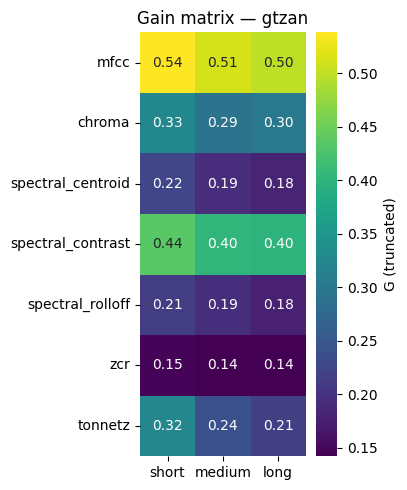

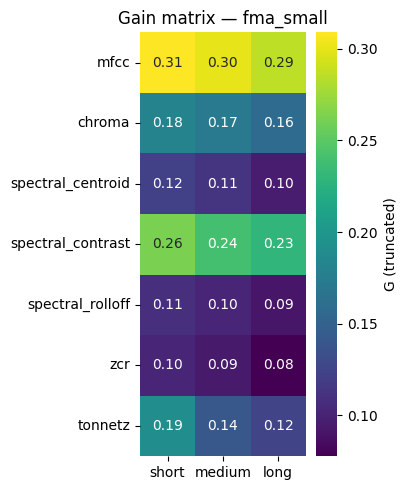

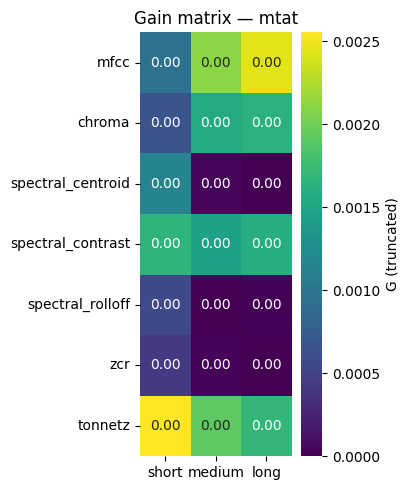

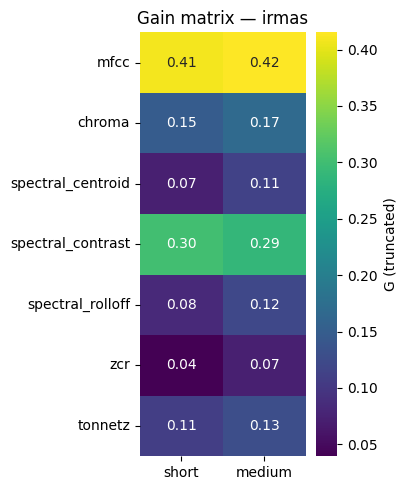

In [15]:
# 7x3 gain matrix heatmap per dataset (G mean per cell; k* annotated).
for name in tsi_results:
    scales = tsi_results[name]['scales']
    descs = list(FEATURE_DIMS)
    M = np.array([[tsi_results[name]['descriptors'][f]['gain_matrix'].get(s, {'mean': np.nan})['mean']
                   for s in scales] for f in descs])
    plt.figure(figsize=(4, 5))
    sns.heatmap(M, annot=True, fmt='.2f', xticklabels=scales, yticklabels=descs,
                cmap='viridis', cbar_kws={'label': 'G (truncated)'})
    plt.title(f"Gain matrix — {name}"); plt.tight_layout(); plt.show()